# Refined Mizuta finite-size BCH comparison

This notebook compares the same ideal MPF algorithm under three rigorous sizing proofs: Low 2019, the printed Mizuta Theorem-3 auxiliary-allocation implementation, and the refined Mizuta implementation that evaluates the Lemma-9/Lemma-10 BCH remainder directly for each $(r,p_0)$. The physical MPF schedule is unchanged.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display
pd.set_option('display.max_rows', 120)

root = Path.cwd().resolve()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root / 'src'))

from hamiltonian_resources import heisenberg_chain, transverse_field_ising
from hamiltonian_resources.multiproduct import select_mpf_segments

METHODS = {
    'Low 2019': 'low2019-l1-ideal-rigorous',
    'Mizuta legacy Theorem 3': 'mizuta2026-theorem3-legacy-ideal-rigorous',
    'Mizuta refined': 'mizuta2026-commutator-ideal-rigorous',
}
MODELS = {
    'open TFIM (J=1, h=3)': lambda n: transverse_field_ising(n, coupling=1.0, field=3.0, periodic=False),
    'open XXX (J=1, h_z=0)': lambda n: heisenberg_chain(n, coupling=1.0, field_z=0.0),
}
SIZES = (4, 8, 16, 32, 50, 75, 100)
TARGETS = np.logspace(-1, -6, 11)
MPF_BRANCHES = 3
MARKERS = {'error': 'o', 'time_1': '^', 'time_2': 's', 'joint_p0': 'D', 'commuting_exact': 'P'}


## Auditable sweep helper

Every row retains the selected order, active constraint, local-error dominance, whether the old first condition passed, and both locality and refined-tail fallback provenance.

In [2]:
def summarize(model, hamiltonian, time, epsilon, label, method):
    estimate = select_mpf_segments(
        hamiltonian, time, epsilon, MPF_BRANCHES, method=method, workers=4
    )
    diagnostics = estimate.segment_diagnostics
    components = dict(estimate.bound_components)
    commutator = components.get('local_commutator_error')
    bch = components.get(
        'total_branchwise_bch_remainder',
        components.get('local_truncated_bch_error'),
    )
    if commutator is None or bch is None:
        dominance = 'not-applicable'
    elif commutator > bch:
        dominance = 'commutator'
    elif commutator < bch:
        dominance = 'BCH'
    else:
        dominance = 'tie'
    legacy_limit = components.get(
        'legacy_first_time_limit', components.get('first_time_limit')
    )
    legacy_pass = (
        None if legacy_limit is None else abs(time) / estimate.segments <= legacy_limit
    )
    return {
        'model': model,
        'N': hamiltonian.num_qubits,
        'time': time,
        'epsilon': epsilon,
        'estimator': label,
        'method': method,
        'segments': estimate.segments,
        'bound': estimate.error,
        'p0': None if diagnostics is None else diagnostics.truncation_order_p0,
        'active_constraint': (
            'not-applicable'
            if diagnostics is None
            else '+'.join(diagnostics.active_constraints)
        ),
        'local_error_dominance': dominance,
        'legacy_first_pass': legacy_pass,
        'exact_commutator_cutoff': estimate.max_exact_nested_commutator_order,
        'locality_fallback': (
            estimate.max_exact_nested_commutator_order < estimate.max_nested_commutator_order
        ),
        'refined_tail_fallback': bool(components.get('refined_tail_fallback', 0.0)),
    }

def constraint_marker(value):
    return MARKERS.get(str(value).split('+')[0], 'x')


## System-size sweep

For both open chains, $t=N$ and $\epsilon=10^{-3}$ at $N=4,8,16,32,50,75,100$.

In [3]:
scaling_rows = []
for model, constructor in MODELS.items():
    for size in SIZES:
        hamiltonian = constructor(size)
        for label, method in METHODS.items():
            scaling_rows.append(
                summarize(model, hamiltonian, float(size), 1e-3, label, method)
            )
scaling = pd.DataFrame(scaling_rows)
display(
    scaling[[
        'model', 'N', 'estimator', 'segments', 'p0', 'active_constraint',
        'local_error_dominance', 'legacy_first_pass',
        'exact_commutator_cutoff', 'locality_fallback', 'refined_tail_fallback',
    ]]
)


,model,N,estimator,segments,p0,active_constraint,local_error_dominance,legacy_first_pass,exact_commutator_cutoff,locality_fallback,refined_tail_fallback
0,"open TFIM (J=1, h=3)",4,Low 2019,123,NaN,error,not-applicable,None,0,False,False
1,"open TFIM (J=1, h=3)",4,Mizuta legacy Theorem 3,321369,25.0,time_1,BCH,True,25,False,False
2,"open TFIM (J=1, h=3)",4,Mizuta refined,1156,5.0,error,commutator,False,5,False,False
3,"open TFIM (J=1, h=3)",8,Low 2019,633,NaN,error,not-applicable,None,0,False,False
4,"open TFIM (J=1, h=3)",8,Mizuta legacy Theorem 3,694157,27.0,time_1,BCH,True,27,False,False
5,"open TFIM (J=1, h=3)",8,Mizuta refined,3323,5.0,error,commutator,False,5,False,False
6,"open TFIM (J=1, h=3)",16,Low 2019,3207,NaN,error,not-applicable,None,0,False,False
7,"open TFIM (J=1, h=3)",16,Mizuta legacy Theorem 3,1439732,28.0,time_1,BCH,True,28,False,False
8,"open TFIM (J=1, h=3)",16,Mizuta refined,9406,5.0,error,commutator,False,5,False,False
9,"open TFIM (J=1, h=3)",32,Low 2019,16140,NaN,error,not-applicable,None,0,False,False


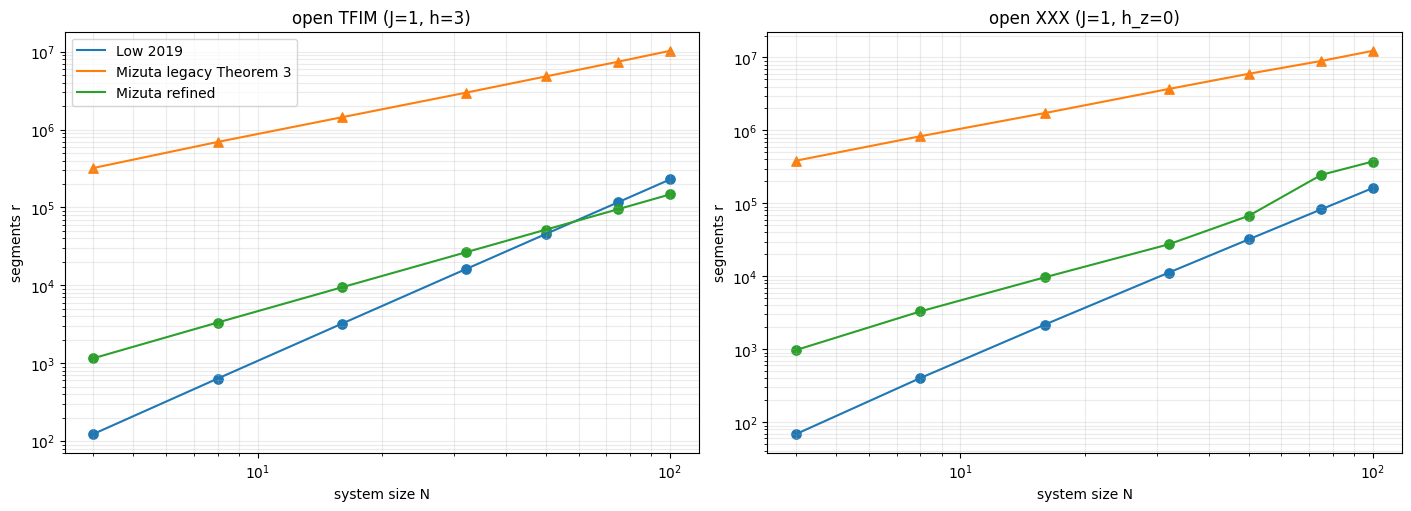

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, model in zip(axes, MODELS, strict=True):
    subset = scaling[scaling['model'] == model]
    for label in METHODS:
        values = subset[subset['estimator'] == label].sort_values('N')
        line, = axis.loglog(values['N'], values['segments'], label=label)
        for _, row in values.iterrows():
            axis.scatter(
                row['N'], row['segments'], color=line.get_color(),
                marker=constraint_marker(row['active_constraint']), s=45,
            )
    axis.set(title=model, xlabel='system size N', ylabel='segments r')
    axis.grid(True, which='both', alpha=0.25)
axes[0].legend()
plt.show()


## Target-error sweep

The target sweep uses 11 logarithmically spaced values from $10^{-1}$ to $10^{-6}$ at $N=t=50$ for both models.

In [5]:
target_rows = []
for model, constructor in MODELS.items():
    hamiltonian = constructor(50)
    for epsilon in TARGETS:
        for label, method in METHODS.items():
            target_rows.append(
                summarize(model, hamiltonian, 50.0, float(epsilon), label, method)
            )
targets = pd.DataFrame(target_rows)
display(
    targets[[
        'model', 'epsilon', 'estimator', 'segments', 'p0', 'active_constraint',
        'local_error_dominance', 'legacy_first_pass',
        'locality_fallback', 'refined_tail_fallback',
    ]]
)


,model,epsilon,estimator,segments,p0,active_constraint,local_error_dominance,legacy_first_pass,locality_fallback,refined_tail_fallback
0,"open TFIM (J=1, h=3)",0.100000,Low 2019,22326,NaN,error,not-applicable,None,False,False
1,"open TFIM (J=1, h=3)",0.100000,Mizuta legacy Theorem 3,4177792,26.0,time_1,BCH,True,False,False
2,"open TFIM (J=1, h=3)",0.100000,Mizuta refined,24063,4.0,error,commutator,False,False,False
3,"open TFIM (J=1, h=3)",0.031623,Low 2019,26467,NaN,error,not-applicable,None,False,False
4,"open TFIM (J=1, h=3)",0.031623,Mizuta legacy Theorem 3,4338476,27.0,time_1,BCH,True,False,False
5,"open TFIM (J=1, h=3)",0.031623,Mizuta refined,29158,5.0,error,commutator,False,False,False
6,"open TFIM (J=1, h=3)",0.010000,Low 2019,31629,NaN,error,not-applicable,None,False,False
7,"open TFIM (J=1, h=3)",0.010000,Mizuta legacy Theorem 3,4499161,28.0,time_1,BCH,True,False,False
8,"open TFIM (J=1, h=3)",0.010000,Mizuta refined,35246,5.0,error,commutator,False,False,False
9,"open TFIM (J=1, h=3)",0.003162,Low 2019,37944,NaN,error,not-applicable,None,False,False


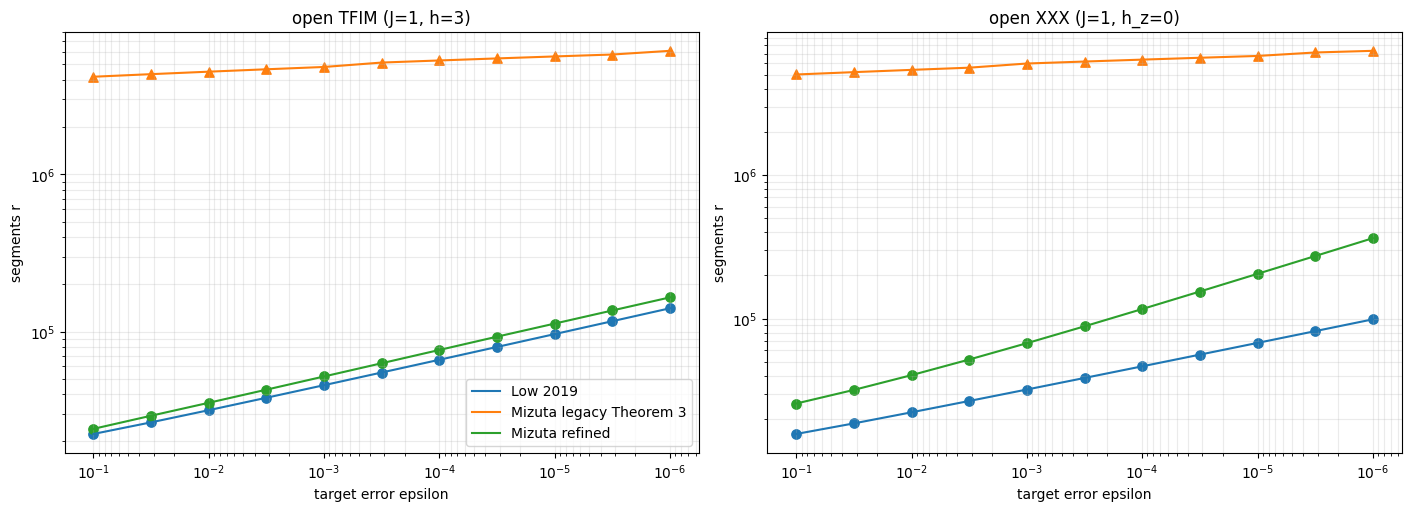

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, model in zip(axes, MODELS, strict=True):
    subset = targets[targets['model'] == model]
    for label in METHODS:
        values = subset[subset['estimator'] == label].sort_values('epsilon')
        line, = axis.loglog(values['epsilon'], values['segments'], label=label)
        for _, row in values.iterrows():
            axis.scatter(
                row['epsilon'], row['segments'], color=line.get_color(),
                marker=constraint_marker(row['active_constraint']), s=45,
            )
    axis.invert_xaxis()
    axis.set(title=model, xlabel='target error epsilon', ylabel='segments r')
    axis.grid(True, which='both', alpha=0.25)
axes[0].legend()
plt.show()

assert tuple(sorted(scaling['N'].unique())) == SIZES
assert len(TARGETS) == 11 and np.isclose(TARGETS[0], 1e-1) and np.isclose(TARGETS[-1], 1e-6)
assert set(scaling['estimator']) == set(METHODS) == set(targets['estimator'])
assert (scaling['segments'] >= 1).all() and (targets['segments'] >= 1).all()
assert (scaling['bound'] <= scaling['epsilon']).all()
assert (targets['bound'] <= targets['epsilon']).all()


## Interpretation

The legacy rows expose the cost of replacing all branch remainders by one auxiliary error and imposing the printed first time condition. The refined rows instead expose the BCH terms needed for the same MPF cancellation argument and certify their branchwise remainder directly. No Hamiltonian, Suzuki schedule, MPF coefficient, exponent, or physical circuit is changed.